In [ ]:

import   kagglehub
yol = kagglehub.dataset_download(  "khlaifiabilel/military-aircraft-recognition-datas  et"  )

print(  "Veri sisteminin yolu:"  , yol)

100%|██████████| 1.13G/1.13G [00:12<00:00, 95.5MB/s]

Extracting files...


Veri kümesi dosyalarının yolu: /root/.cache/kagglehub/datasets/khlaifiabilel/military-aircraft-recognition-dataset/versions/1


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import xml.etree.ElementTree as ET

def prepare_mar20_ysa(base_path, split='train', target_size=(64, 64)):
    X, y = [], []

    img_dir = os.path.join(base_path, 'JPEGImages')

    annotations_dir = os.path.join(base_path, 'Annotations', 'Horizontal Bounding Boxes')
    image_set_path = os.path.join(base_path, 'ImageSets', 'Main', f'{split}.txt')

    if not os.path.exists(img_dir):
        print(f"Hata: {img_dir} yolu bulunamadı!")
        return None, None
    if not os.path.exists(annotations_dir):
        print(f"Hata: {annotations_dir} yolu bulunamadı!")
        return None, None
    if not os.path.exists(image_set_path):
        print(f"Hata: {image_set_path} yolu bulunamadı! Lütfen split adını kontrol edin ('train', 'val', 'test').")
        return None, None

    with open(image_set_path, 'r') as f:
        image_filenames = [line.strip() for line in f.readlines()]

    class_map = {}
    next_class_id = 0

    skipped_image_none = 0
    skipped_annotation_missing = 0
    skipped_crop_empty = 0
    total_processed_objects = 0

    for img_name_without_ext in tqdm(image_filenames, desc=f"Uçaklar Kesiliyor ({split})"):
        img_path = os.path.join(img_dir, f'{img_name_without_ext}.jpg')
        annotation_path = os.path.join(annotations_dir, f'{img_name_without_ext}.xml')

        image = cv2.imread(img_path)
        if image is None:
            skipped_image_none += 1
            continue

        h, w, _ = image.shape

        if os.path.exists(annotation_path):
            try:
                tree = ET.parse(annotation_path)
                root = tree.getroot()

                for obj in root.findall('object'):
                    class_name = obj.find('name').text
                    if class_name not in class_map:
                        class_map[class_name] = next_class_id
                        next_class_id += 1
                    class_id = class_map[class_name]

                    bbox = obj.find('bndbox')
                    x1 = int(float(bbox.find('xmin').text))
                    y1 = int(float(bbox.find('ymin').text))
                    x2 = int(float(bbox.find('xmax').text))
                    y2 = int(float(bbox.find('ymax').text))


                    x1 = max(0, x1)
                    y1 = max(0, y1)
                    x2 = min(w, x2)
                    y2 = min(h, y2)


                    crop = image[y1:y2, x1:x2]

                    if crop.size == 0 or crop.shape[0] == 0 or crop.shape[1] == 0:
                        skipped_crop_empty += 1
                        continue


                    crop = cv2.resize(crop, target_size)
                    # Removed grayscale conversion for color images
                    X.append(crop) # Append color image directly
                    y.append(class_id)
                    total_processed_objects += 1
            except Exception as e:
                print(f"Error parsing annotation {annotation_path}: {e}")
                continue
        else:
            skipped_annotation_missing += 1

    print(f"\n--- Veri Hazırlığı Özeti ({split}) ---")
    print(f"ImageSet dosyasındaki toplam görsel: {len(image_filenames)}")
    print(f"cv2.imread'in None döndürdüğü görseller: {skipped_image_none}")
    print(f"Eksik etiketleme dosyasına sahip görseller: {skipped_annotation_missing}")
    print(f"Kesme işleminin boş görselle sonuçlandığı nesneler: {skipped_crop_empty}")
    print(f"Başarıyla işlenen toplam nesne: {total_processed_objects}")
    print(f"X içindeki örnek sayısı: {len(X)}")
    print(f"y içindeki örnek sayısı: {len(y)}")

    return np.array(X), np.array(y)

In [ ]:
X_train, y_train = prepare_mar20_ysa(yol, split='train')

Uçaklar Kesiliyor (train): 100%|██████████| 1331/1331 [00:20<00:00, 65.54it/s]



--- Veri Hazırlığı Özeti (train) ---
ImageSet dosyasındaki toplam görsel: 1331
cv2.imread'in None döndürdüğü görseller: 0
Eksik etiketleme dosyasına sahip görseller: 0
Kesme işleminin boş görselle sonuçlandığı nesneler: 0
Başarıyla işlenen toplam nesne: 7870
X içindeki örnek sayısı: 7870
y içindeki örnek sayısı: 7870


In [ ]:
X_test, y_test = prepare_mar20_ysa(yol, split='test')

Uçaklar Kesiliyor (test): 100%|██████████| 2511/2511 [00:39<00:00, 63.05it/s]



--- Veri Hazırlığı Özeti (test) ---
ImageSet dosyasındaki toplam görsel: 2511
cv2.imread'in None döndürdüğü görseller: 0
Eksik etiketleme dosyasına sahip görseller: 0
Kesme işleminin boş görselle sonuçlandığı nesneler: 0
Başarıyla işlenen toplam nesne: 14471
X içindeki örnek sayısı: 14471
y içindeki örnek sayısı: 14471


In [ ]:
X_combined = np.concatenate((X_train, X_test), axis=0)
y_combined = np.concatenate((y_train, y_test), axis=0)

print(f"Birleştirilmiş X veri setinin toplam örnek sayısı: {X_combined.shape[0]}")
print(f"Birleştirilmiş y etiket setinin toplam örnek sayısı: {y_combined.shape[0]}")

Birleştirilmiş X veri setinin toplam örnek sayısı: 22341
Birleştirilmiş y etiket setinin toplam örnek sayısı: 22341


### Birleştirilmiş Veri Setinden Düşük Kaliteli Görüntüleri Çıkarma

Şimdi `X_combined` ve `y_combined` birleştirilmiş veri setinden düşük kaliteli (bulanık) görselleri tespit edip çıkaracağız. Bu işlem, ilerideki eğitim süreçlerinde daha temiz bir veri setine sahip olmamızı sağlayacaktır.

### Düşük Kaliteli Görüntüleri Tespit Etme ve Görselleştirme

Bu bölümde, eğitim setimizdeki (dengelenmiş ve arttırılmış olan `X_train_augmented_balanced`) düşük kaliteli görselleri tespit etmek için bir fonksiyon yazacağız. Görüntü kalitesi için **Laplacian varyansı** yöntemini kullanacağız. Bir görüntünün Laplacian operatörünün varyansı ne kadar düşükse, görüntü o kadar bulanıktır. Bu yöntemi kullanarak bulanık (yani düşük kaliteli) görselleri belirleyip görselleştireceğiz.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def estimate_image_quality(image):
    """
    Bir görüntünün bulanıklık seviyesini Laplacian varyansı ile tahmin eder.
    Daha düşük değerler, daha bulanık görüntülere işaret eder.
    """
    # cv2.cvtColor ve cv2.Laplacian'ın beklediği uint8 formatına dönüştür
    if image.dtype != np.uint8:
        # Eğer görüntü normalize edilmişse (0-1 aralığında), 255 ile çarpıp uint8'e çevirmeliyiz.
        # Mevcut durumda X_train_augmented_balanced 0-255 aralığında float değerler içeriyor.
        image = image.astype(np.uint8)

    # Gri tonlamalıya dönüştür
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    # Laplacian operatörünü uygula ve varyansını hesapla
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def find_and_visualize_low_quality_images(images, num_samples=10, quality_threshold=100.0):
    """
    Verilen görüntülerden düşük kaliteli olanları tespit eder ve görselleştirir.

    Args:
        images (np.ndarray): Görsellerin numpy dizisi (N, H, W, C).
        num_samples (int): Görselleştirilecek düşük kaliteli örnek sayısı.
        quality_threshold (float): Düşük kalite olarak kabul edilecek Laplacian varyansı eşik değeri.
                                   Bu değer deneysel olarak ayarlanmalıdır.

    Returns:
        list: Düşük kaliteli olarak tespit edilen görsellerin indeksleri.
        list: Tüm görsellerin kalite skorları.
    """
    quality_scores = []
    for i in range(len(images)):
        score = estimate_image_quality(images[i])
        quality_scores.append(score)

    low_quality_indices = [i for i, score in enumerate(quality_scores) if score < quality_threshold]
    print(f"Toplam {len(low_quality_indices)} adet düşük kaliteli görsel tespit edildi (eşik: {quality_threshold}).")

    if len(low_quality_indices) > 0:
        print(f"İlk {min(num_samples, len(low_quality_indices))} düşük kaliteli görsel örneği gösteriliyor...")
        plt.figure(figsize=(15, 3))
        for i, idx in enumerate(low_quality_indices[:num_samples]):
            ax = plt.subplot(1, num_samples, i + 1)
            plt.imshow(images[idx].astype(np.uint8)) # Görselleştirmede de uint8 kullan
            plt.title(f"Score: {quality_scores[idx]:.1f}")
            plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("Düşük kaliteli görsel bulunamadı veya eşik değeri çok yüksek.")

    return low_quality_indices, quality_scores

Toplam 2394 adet düşük kaliteli görsel tespit edildi (eşik: 75.0).
İlk 10 düşük kaliteli görsel örneği gösteriliyor...


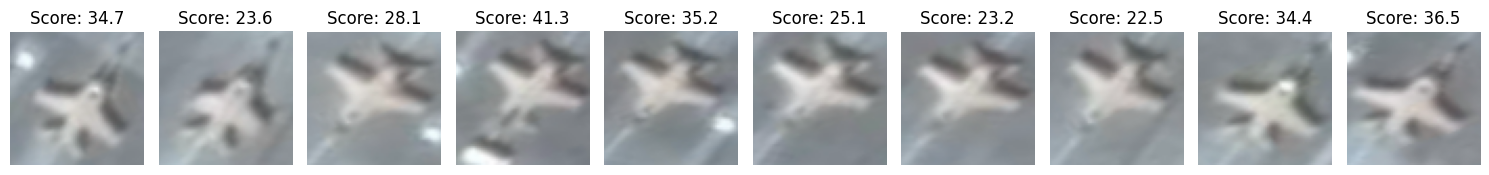

Orijinal birleştirilmiş veri seti boyutu: 22341
Filtrelenmiş birleştirilmiş veri seti boyutu: 19947
Filtrelenmiş X_combined_filtered şekli: (19947, 64, 64, 3)
Filtrelenmiş y_combined_filtered şekli: (19947,)


In [ ]:
# X_combined üzerindeki düşük kaliteli görselleri tespit et
# quality_threshold'u ihtiyaçlarınıza göre ayarlayabilirsiniz.
low_quality_indices_combined, _ = find_and_visualize_low_quality_images(X_combined, quality_threshold=75.0)

# Yüksek kaliteli görsellerin indekslerini bul
high_quality_indices_combined = np.array([i for i in range(len(X_combined)) if i not in low_quality_indices_combined])

# Yeni, filtrelenmiş birleştirilmiş veri setlerini oluştur
X_combined_filtered = X_combined[high_quality_indices_combined]
y_combined_filtered = y_combined[high_quality_indices_combined]

print(f"Orijinal birleştirilmiş veri seti boyutu: {X_combined.shape[0]}")
print(f"Filtrelenmiş birleştirilmiş veri seti boyutu: {X_combined_filtered.shape[0]}")
print(f"Filtrelenmiş X_combined_filtered şekli: {X_combined_filtered.shape}")
print(f"Filtrelenmiş y_combined_filtered şekli: {y_combined_filtered.shape}")

# Artık sonraki adımlarda (train_test_split vb.) X_combined_filtered ve y_combined_filtered kullanılabilir.

### Düşük Kaliteli Görüntüleri Eğitim Setinden Çıkarma

Yukarıda tespit edilen düşük kaliteli görselleri (`low_quality_image_indices` tarafından belirtilenler) eğitim setimizden (`X_train_augmented_balanced` ve `y_train_augmented_balanced`) çıkaracağız. Bu, modelin eğitimini yalnızca daha yüksek kaliteli görsellerle gerçekleştirmesini sağlayacaktır.

In [ ]:
# Bu hücre, birleştirilmiş veri seti (X_combined) baştan filtrelendiği için artık gerekli değildir.
# X_train_split ve y_train_split zaten filtrelenmiş verileri içerir.

### Düşük Kaliteli Görüntüleri Test Setinden Çıkarma

Benzer şekilde, modelin performansını daha doğru bir şekilde değerlendirebilmek için düşük kaliteli görselleri test setinden (`X_test_split` ve `y_test_split`) çıkaracağız.

In [ ]:
# Bu hücre, birleştirilmiş veri seti (X_combined) baştan filtrelendiği için artık gerekli değildir.
# X_test_split ve y_test_split zaten filtrelenmiş verileri içerir.

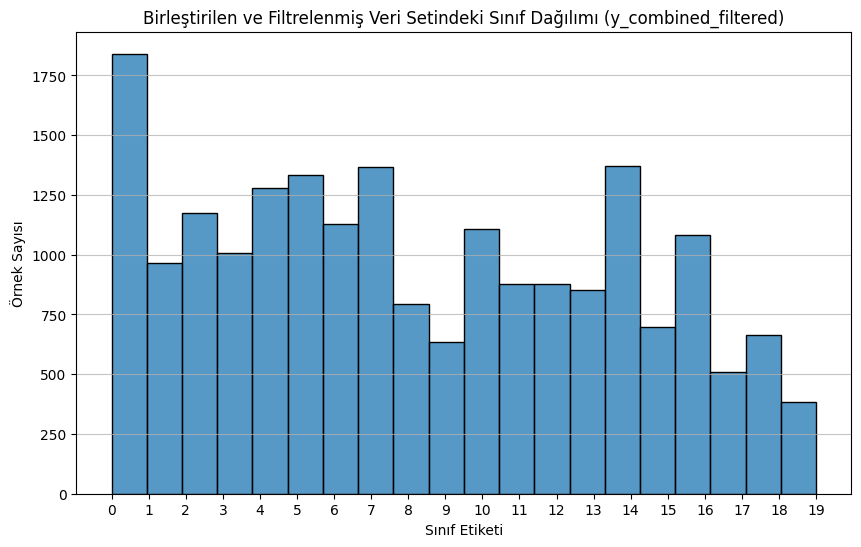

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(y_combined_filtered, bins=len(np.unique(y_combined_filtered)), kde=False)
plt.title('Birleştirilen ve Filtrelenmiş Veri Setindeki Sınıf Dağılımı (y_combined_filtered)')
plt.xlabel('Sınıf Etiketi')
plt.ylabel('Örnek Sayısı')
plt.xticks(np.arange(len(np.unique(y_combined_filtered))))
plt.grid(axis='y', alpha=0.75)
plt.show()

Displaying 10 random sample cropped aircraft images from original X_train:


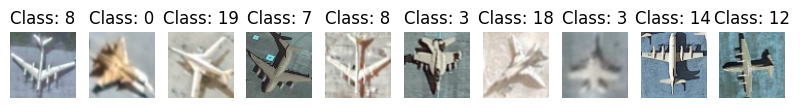

In [ ]:
import matplotlib.pyplot as plt
import random

num_samples_to_display = 10

if X_train is not None and len(X_train) > 0:
    print(f"Displaying {num_samples_to_display} random sample cropped aircraft images from original X_train:")
    plt.figure(figsize=(10, 2))

    random_indices = random.sample(range(len(X_train)), min(num_samples_to_display, len(X_train)))

    for i, idx in enumerate(random_indices):
        ax = plt.subplot(1, num_samples_to_display, i + 1)

        img = X_train[idx] # No reshape needed if already 64x64x3, or reshape to (64, 64, 3)
        plt.imshow(img)
        plt.title(f"Class: {y_train[idx]}")
        plt.axis('off')
    plt.show()
else:
    print("No training data (X_train) available to display.")

In [ ]:
from sklearn.model_selection import train_test_split


X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_combined_filtered, y_combined_filtered, test_size=0.3, random_state=42, stratify=y_combined_filtered
)

print(f"Yeni eğitim seti X_train_split şekli: {X_train_split.shape}")
print(f"Yeni eğitim seti y_train_split şekli: {y_train_split.shape}")
print(f"Yeni test seti X_test_split şekli: {X_test_split.shape}")
print(f"Yeni test seti y_test_split şekli: {y_test_split.shape}")

Yeni eğitim seti X_train_split şekli: (13962, 64, 64, 3)
Yeni eğitim seti y_train_split şekli: (13962,)
Yeni test seti X_test_split şekli: (5985, 64, 64, 3)
Yeni test seti y_test_split şekli: (5985,)


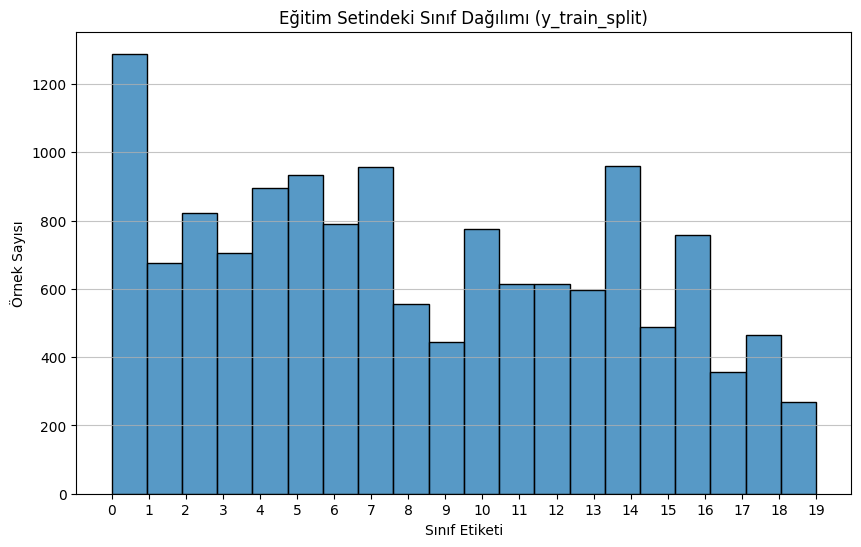

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.histplot(y_train_split, bins=len(np.unique(y_train_split)), kde=False)
plt.title('Eğitim Setindeki Sınıf Dağılımı (y_train_split)')
plt.xlabel('Sınıf Etiketi')
plt.ylabel('Örnek Sayısı')
plt.xticks(np.arange(len(np.unique(y_train_split))))
plt.grid(axis='y', alpha=0.75)
plt.show()


### Normalize Edilmiş Veri Setlerini Güncelleme

Test setini de filtrelediğimiz için, normalize edilmiş test setini (`X_test_split_normalized`) yeni filtrelenmiş verilerle (`X_test_split_filtered`) yeniden oluşturmamız gerekiyor. Ayrıca, artık veri artırma ve dengeleme işlemleri de `X_train_split_filtered` ve `y_train_split_filtered` üzerinden yapılacağı için, bu kısımları da buna göre güncelleyeceğiz.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models
import numpy as np


# Calculate num_classes from the combined original labels, as it represents the total number of unique classes.
# This should be consistent regardless of balancing or splitting.
num_classes = len(np.unique(y_combined))
print(f"Toplam sınıf sayısı: {num_classes}")


# Model tanımı
model = models.Sequential()


# Input shape of the first Conv2D layer corrected to 128x128. Input data (X_train_balanced_normalized)
# will already be in (N, 128, 128, 1) format.
model.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=(64, 64, 3))) # Changed input_shape to 3 channels
model.add(layers.MaxPooling2D((2, 2)))


model.add(layers.Conv2D(64, (5, 5), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))


model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))


model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))



model.add(layers.Flatten())


model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(num_classes, activation='softmax'))
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Toplam sınıf sayısı: 20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │        10,260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 615,124 (2.35 MB)

 Trainable params: 615,124 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X_train_normalized = X_train_split / 255.0

history = model.fit(X_train_normalized,
                    y_train_split,
                    epochs=30,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.1439 - loss: 2.7047 - val_accuracy: 0.2932 - val_loss: 2.1826
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.3750 - loss: 1.9232 - val_accuracy: 0.4175 - val_loss: 1.7063
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5351 - loss: 1.4200 - val_accuracy: 0.5822 - val_loss: 1.2690
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6173 - loss: 1.1372 - val_accuracy: 0.6459 - val_loss: 1.0714
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6898 - loss: 0.9188 - val_accuracy: 0.6405 - val_loss: 1.0526
Epoch 6/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7463 - loss: 0.7360 - val_accuracy: 0.6749 - val_loss: 0.9690
Epoch 7/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7891 - loss: 0.6049 - val_accuracy: 0.7025 - val_loss: 0.9109
Epoch 8/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8336 - loss: 0.4755 - val_acc

In [ ]:
X_test_normalized = X_test_split / 255.0

loss, accuracy = model.evaluate(X_test_normalized, y_test_split, verbose=0)
print(f"Test Seti Doğruluğu: {accuracy:.4f}")
print(f"Test Seti Kaybı: {loss:.4f}")

Test Seti Doğruluğu: 0.7240
Test Seti Kaybı: 1.6469


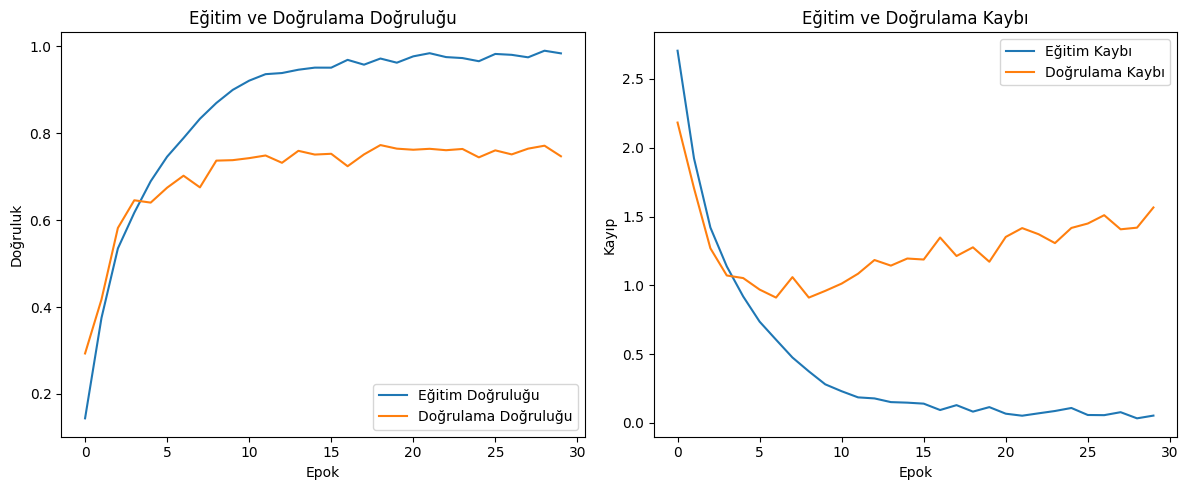

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Eğitim ve Doğrulama Doğruluğu')
plt.xlabel('Epok')
plt.ylabel('Doğruluk')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.xlabel('Epok')
plt.ylabel('Kayıp')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Veri arttırma (Data Augmentation) için ImageDataGenerator oluşturma
train_datagen = ImageDataGenerator(
    rotation_range=20,      # Rastgele 20 dereceye kadar döndürme
    width_shift_range=0.1,  # Genişliğin %10'una kadar yatay kaydırma
    height_shift_range=0.1, # Yüksekliğin %10'una kadar dikey kaydırma
    shear_range=0.1,        # Kaydırma dönüşümleri
    zoom_range=0.1,         # Rastgele yakınlaştırma
    horizontal_flip=True,   # Rastgele yatay çevirme
    fill_mode='nearest'     # Kaydırılan veya döndürülen pikselleri doldurma stratejisi
)

# Oluşturulan ImageDataGenerator'ı eğitim verisine uydurma
# train_datagen.fit(X_train_reshaped) # Bu satır, X_train_reshaped henüz tanımlanmadığı için hataya neden oluyor ve mevcut parametreler için gerekli değil.

print("Veri arttırma jeneratörü oluşturuldu ve eğitim verisine uyduruldu.")

Veri arttırma jeneratörü oluşturuldu ve eğitim verisine uyduruldu.


In [ ]:
from collections import Counter
import numpy as np
import random # For random.sample

# Now, apply augmentation and balancing only to the training split
# X_train_split is already (N, 64, 64, 3) after previous steps, no need for reshape here
X_train_split_for_augmentation = X_train_split # X_train_split artık filtrelenmiş veriyi içeriyor
y_train_split_for_augmentation = y_train_split # y_train_split artık filtrelenmiş veriyi içeriyor

# Mevcut sınıf dağılımını kontrol et (on X_train_split data)
class_counts = Counter(y_train_split_for_augmentation)
print("Filtrelenmiş Eğitim Veri Setindeki Sınıf Dağılımı (train_test_split sonrası):")
for class_id in sorted(class_counts.keys()):
    print(f"Sınıf {class_id}: {class_counts[class_id]} örnek")

target_samples_per_class = 1000

X_augmented_list = list(X_train_split_for_augmentation) # Listeye çevirerek kolayca ekleme yap
y_augmented_list = list(y_train_split_for_augmentation)

print(f"\nHer sınıf için hedef örnek sayısı: {target_samples_per_class}")

# Upsampling: Sınıfları hedef örnek sayısına kadar arttırma
for class_id in sorted(np.unique(y_train_split_for_augmentation)):
    current_count = class_counts[class_id]
    if current_count < target_samples_per_class:
        num_to_generate = target_samples_per_class - current_count
        print(f"Sınıf {class_id} için {num_to_generate} ek örnek oluşturuluyor...")

        # Sadece bu sınıfa ait görselleri ve etiketleri seç
        class_indices = np.where(y_train_split_for_augmentation == class_id)[0]
        X_class = X_train_split_for_augmentation[class_indices]
        y_class = y_train_split_for_augmentation[class_indices]

        # Veri arttırma jeneratörünü sadece bu sınıfa ait görsellerle besle
        # Ensure that X_class is properly fed to the flow, train_datagen can handle 3 channels
        aug_generator = train_datagen.flow(X_class, y_class, batch_size=1, shuffle=False)

        generated_count = 0
        for _ in range(num_to_generate):
            X_batch, y_batch = next(aug_generator)
            X_augmented_list.append(X_batch[0])
            y_augmented_list.append(y_batch[0])
            generated_count += 1
        print(f"Sınıf {class_id} için {generated_count} örnek başArıyla oluşturuldu.")

X_temp_augmented = np.array(X_augmented_list)
y_temp_augmented = np.array(y_augmented_list)

post_upsample_class_counts = Counter(y_temp_augmented)

X_train_augmented_balanced = []
y_train_augmented_balanced = []

print("\nDownsampling işiemi kontrol ediliyor...")
for class_id in sorted(np.unique(y_temp_augmented)):
    current_count = post_upsample_class_counts[class_id]
    class_indices = np.where(y_temp_augmented == class_id)[0]

    if current_count > target_samples_per_class:
        print(f"Sınıf {class_id} için {current_count} örnek var, {target_samples_per_class} örneğae düşörülecek...")
        sampled_indices = random.sample(list(class_indices), target_samples_per_class)
        X_train_augmented_balanced.extend(X_temp_augmented[sampled_indices])
        y_train_augmented_balanced.extend(y_temp_augmented[sampled_indices])
        print(f"Sınıf {class_id} için {target_samples_per_class} örnek seçildi.")
    else:
        X_train_augmented_balanced.extend(X_temp_augmented[class_indices])
        y_train_augmented_balanced.extend(y_temp_augmented[class_indices])

# Output of this cell should be the balanced and augmented training data
X_train_augmented_balanced = np.array(X_train_augmented_balanced)
y_train_augmented_balanced = np.array(y_train_augmented_balanced)

print(f"\nDengelenmiş ve arttırılmış eğitim veri seti X_train_augmented_balanced boyutu: {X_train_augmented_balanced.shape}")
print(f"Dengelenmiş ve arttırılmış eğitim veri seti y_train_augmented_balanced boyutu: {y_train_augmented_balanced.shape}")

final_class_counts = Counter(y_train_augmented_balanced)
print("\nDengelenmiş ve Arttırılmış Eğitim Veri Setindeki Sınıf Dağılımı:")
for class_id in sorted(final_class_counts.keys()):
    print(f"Sınıf {class_id}: {final_class_counts[class_id]} örnek")

Filtrelenmiş Eğitim Veri Setindeki Sınıf Dağılımı (train_test_split sonrası):
Sınıf 0: 1289 örnek
Sınıf 1: 676 örnek
Sınıf 2: 823 örnek
Sınıf 3: 706 örnek
Sınıf 4: 895 örnek
Sınıf 5: 934 örnek
Sınıf 6: 789 örnek
Sınıf 7: 956 örnek
Sınıf 8: 555 örnek
Sınıf 9: 444 örnek
Sınıf 10: 775 örnek
Sınıf 11: 613 örnek
Sınıf 12: 615 örnek
Sınıf 13: 596 örnek
Sınıf 14: 960 örnek
Sınıf 15: 489 örnek
Sınıf 16: 757 örnek
Sınıf 17: 357 örnek
Sınıf 18: 465 örnek
Sınıf 19: 268 örnek

Her sınıf için hedef örnek sayısı: 1000
Sınıf 1 için 324 ek örnek oluşturuluyor...
Sınıf 1 için 324 örnek başArıyla oluşturuldu.
Sınıf 2 için 177 ek örnek oluşturuluyor...
Sınıf 2 için 177 örnek başArıyla oluşturuldu.
Sınıf 3 için 294 ek örnek oluşturuluyor...
Sınıf 3 için 294 örnek başArıyla oluşturuldu.
Sınıf 4 için 105 ek örnek oluşturuluyor...
Sınıf 4 için 105 örnek başArıyla oluşturuldu.
Sınıf 5 için 66 ek örnek oluşturuluyor...
Sınıf 5 için 66 örnek başArıyla oluşturuldu.
Sınıf 6 için 211 ek örnek oluşturuluyor...
Sını

In [ ]:
# Sadece eğitim setini normalize et (dengelenmiş ve arttırılmış, filtrelenmiş veriden)
X_train_augmented_balanced_normalized = X_train_augmented_balanced / 255.0

# Test setini normalize et (yeni filtrelenmiş test verisi)
X_test_split_normalized = X_test_split / 255.0 # X_test_split artık filtrelenmiş veriyi içeriyor

print(f"Dengelenmiş ve arttırılmış yeni eğitim seti X_train_augmented_balanced_normalized şekli: {X_train_augmented_balanced_normalized.shape}")
print(f"Dengelenmiş ve arttırılmış yeni eğitim seti y_train_augmented_balanced şekli: {y_train_augmented_balanced.shape}")
print(f"Normalize edilmiş filtrelenmiş test seti X_test_split_normalized şekli: {X_test_split_normalized.shape}")
print(f"Filtrelenmiş test seti y_test_split şekli: {y_test_split.shape}")

Dengelenmiş ve arttırılmış yeni eğitim seti X_train_augmented_balanced_normalized şekli: (20000, 64, 64, 3)
Dengelenmiş ve arttırılmış yeni eğitim seti y_train_augmented_balanced şekli: (20000,)
Normalize edilmiş filtrelenmiş test seti X_test_split_normalized şekli: (5985, 64, 64, 3)
Filtrelenmiş test seti y_test_split şekli: (5985,)


### Eğitim Setinden Rastgele Örnek Uçak Görüntülerini Görüntüleme

Veri dengeleme ve eğitim/test ayrımı yapıldıktan sonra, şimdi eğitim setimizden rastgele seçilmiş bazı kırpılmış uçak görsellerini ve bunların karşılık gelen sınıf etiketlerini görselleştirelim.

10 adet rastgele kırpılmış uçak görseli görüntüleniyor (X_train_split'ten):


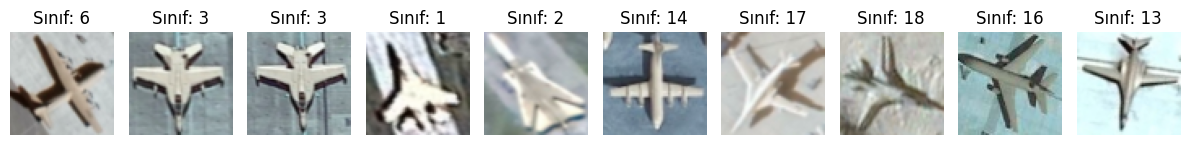

In [ ]:
import matplotlib.pyplot as plt
import random

num_samples_to_display = 10

if X_train_split is not None and len(X_train_split) > 0:
    print(f"{num_samples_to_display} adet rastgele kırpılmış uçak görseli görüntüleniyor (X_train_split'ten):")
    plt.figure(figsize=(12, 3))

    random_indices = random.sample(range(len(X_train_split)), min(num_samples_to_display, len(X_train_split)))

    for i, idx in enumerate(random_indices):
        ax = plt.subplot(1, num_samples_to_display, i + 1)
        img = X_train_split[idx]
        plt.imshow(img)
        plt.title(f"Sınıf: {y_train_split[idx]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Görüntülenecek eğitim verisi (X_train_split) mevcut değil.")

In [ ]:
# Modeli dengelenmiş ve arttırılmış eğitim veri setiyle eğitme, orijinal test setini doğrulama için kullanma
history_balanced_augmented = model.fit(train_datagen.flow(X_train_augmented_balanced_normalized, y_train_augmented_balanced, batch_size=64),
                                       epochs=30,
                                       validation_data=(X_test_split_normalized, y_test_split),
                                       verbose=1)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 94ms/step - accuracy: 0.2140 - loss: 2.4296 - val_accuracy: 0.3754 - val_loss: 1.9405
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.4044 - loss: 1.7861 - val_accuracy: 0.4429 - val_loss: 1.6416
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 90ms/step - accuracy: 0.4825 - loss: 1.5392 - val_accuracy: 0.5586 - val_loss: 1.2811
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.5337 - loss: 1.3648 - val_accuracy: 0.5962 - val_loss: 1.1882
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.5727 - loss: 1.2421 - val_accuracy: 0.6182 - val_loss: 1.0951
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.6023 - loss: 1.1457 - val_accuracy: 0.6660 - val_loss: 0.9696
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.6273 - loss: 1.0755 - val_accuracy: 0.6692 - val_loss: 0.9543
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.6489 - loss: 0.9990 - 

In [ ]:
loss_balanced, accuracy_balanced = model.evaluate(X_test_split_normalized, y_test_split, verbose=0)
print(f"Test Seti Doğruluğu (Dengelenmiş ve Arttırılmış Eğitim Verisi ile): {accuracy_balanced:.4f}")
print(f"Test Seti Kaybı (Dengelenmiş ve Arttırılmış Eğitim Verisi ile): {loss_balanced:.4f}")

Test Seti Doğruluğu (Dengelenmiş ve Arttırılmış Eğitim Verisi ile): 0.7947
Test Seti Kaybı (Dengelenmiş ve Arttırılmış Eğitim Verisi ile): 0.6200


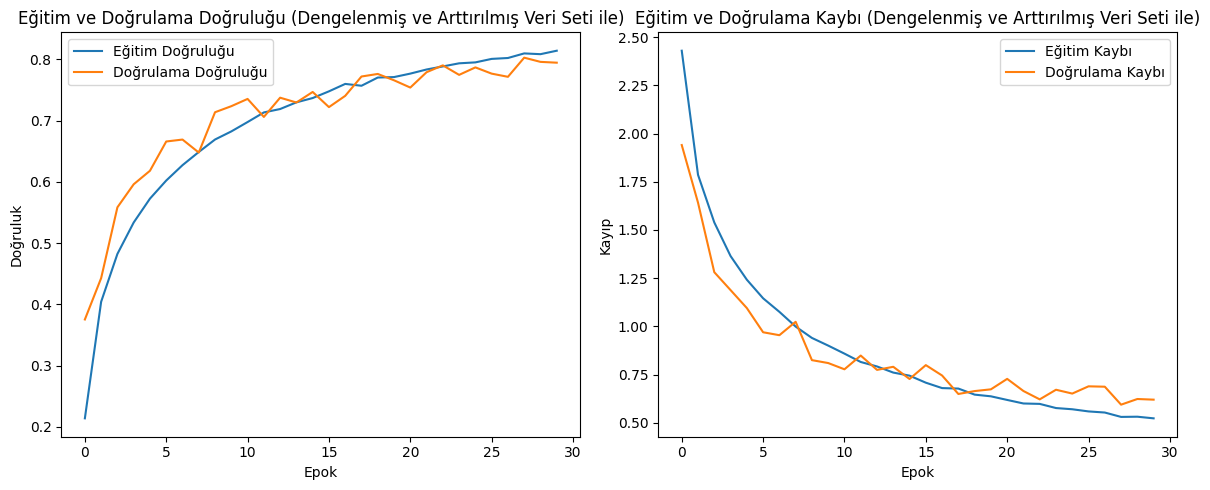

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_balanced_augmented.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history_balanced_augmented.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Eğitim ve Doğrulama Doğruluğu (Dengelenmiş ve Arttırılmış Veri Seti ile)')
plt.xlabel('Epok')
plt.ylabel('Doğruluk')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history_balanced_augmented.history['loss'], label='Eğitim Kaybı')
plt.plot(history_balanced_augmented.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Eğitim ve Doğrulama Kaybı (Dengelenmiş ve Arttırılmış Veri Seti ile)')
plt.xlabel('Epok')
plt.ylabel('Kayıp')
plt.legend()

plt.tight_layout()
plt.show()

### Transfer Öğrenme Modeli Oluşturma (Ham Veri Seti Üzerine)

Ham veri seti (yani `train_test_split` sonrası dengelenmemiş ve veri arttırılmamış veriler) üzerinde transfer öğrenme uygulamak için `MobileNetV2` gibi önceden eğitilmiş bir modeli temel alacağız. Modelin ağırlıklarını dondurarak özellik çıkarıcı olarak kullanacak, üzerine kendi sınıflandırma katmanlarımızı ekleyerek modelimizi eğiteceğiz.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np

# Calculate num_classes from the combined original labels
num_classes = len(np.unique(y_combined))
print(f"Toplam sınıf sayısı: {num_classes}")

# VGG16 taban modelini yükle
# weights='imagenet' ile önceden eğitilmiş ağırlıkları kullan
# include_top=False ile son katmanları (sınıflandırma katmanları) dahil etme
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Taban modeldeki katmanları dondur (ağırlıklarını eğitme)
for layer in base_model.layers:
    layer.trainable = False

# Taban modelin üzerine kendi sınıflandırma katmanlarımızı ekle
x = base_model.output
x = GlobalAveragePooling2D()(x) # Özellik haritalarını tek bir vektöre indirge
x = Dense(256, activation='relu')(x) # Yeni tam bağlı katman
predictions = Dense(num_classes, activation='softmax')(x) # Çıkış katmanı

# Yeni modeli oluştur
transfer_model = Model(inputs=base_model.input, outputs=predictions)

# Modeli derle
transfer_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

print("Transfer öğrenme modeli başarıyla oluşturuldu (VGG16 ile).")

Toplam sınıf sayısı: 20
Transfer öğrenme modeli başarıyla oluşturuldu (VGG16 ile).


In [ ]:
transfer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,851,156 (56.65 MB)

 Trainable params: 136,468 (533.08 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Transfer Öğrenme Modelini Eğitme

Şimdi oluşturduğumuz transfer öğrenme modelini, veri arttırma ve dengeleme yapılmamış olan `X_train_split` ve `y_train_split` verileri üzerinde eğitelim. `X_test_split` ve `y_test_split` ise doğrulama için kullanılacak.

In [ ]:
# X_train_split ve X_test_split verilerini normalize et
X_train_split_normalized = X_train_split / 255.0
X_test_split_normalized = X_test_split / 255.0

history_transfer = transfer_model.fit(X_train_split_normalized,
                                      y_train_split,
                                      epochs=30,
                                      batch_size=64,
                                      validation_data=(X_test_split_normalized, y_test_split),
                                      verbose=1)


Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - accuracy: 0.3982 - loss: 1.9554 - val_accuracy: 0.4877 - val_loss: 1.5870
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.5419 - loss: 1.4117 - val_accuracy: 0.5514 - val_loss: 1.3573
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.5984 - loss: 1.2189 - val_accuracy: 0.5953 - val_loss: 1.2172
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.6374 - loss: 1.1011 - val_accuracy: 0.6185 - val_loss: 1.1423
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.6624 - loss: 1.0145 - val_accuracy: 0.6232 - val_loss: 1.0970
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.6801 - loss: 0.9495 - val_accuracy: 0.6470 - val_loss: 1.0446
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.7077 - loss: 0.8823 - val_accuracy: 0.6555 - val_loss: 1.0043
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.7212 - loss: 0.8329 - 

### Transfer Öğrenme Modeli Değerlendirmesi

Eğitim tamamlandıktan sonra, transfer öğrenme modelinin test seti üzerindeki performansını değerlendirelim.

In [ ]:
loss_transfer, accuracy_transfer = transfer_model.evaluate(X_test_split_normalized, y_test_split, verbose=0)
print(f"Test Seti Doğruluğu (Transfer Öğrenme ile): {accuracy_transfer:.4f}")
print(f"Test Seti Kaybı (Transfer Öğrenme ile): {loss_transfer:.4f}")

Test Seti Doğruluğu (Transfer Öğrenme ile): 0.7404
Test Seti Kaybı (Transfer Öğrenme ile): 0.8181


### Eğitim ve Doğrulama Grafikleri (Transfer Öğrenme)

Transfer öğrenme modelinin eğitim ve doğrulama doğruluğu ile kayıp metriklerini görselleştirelim.

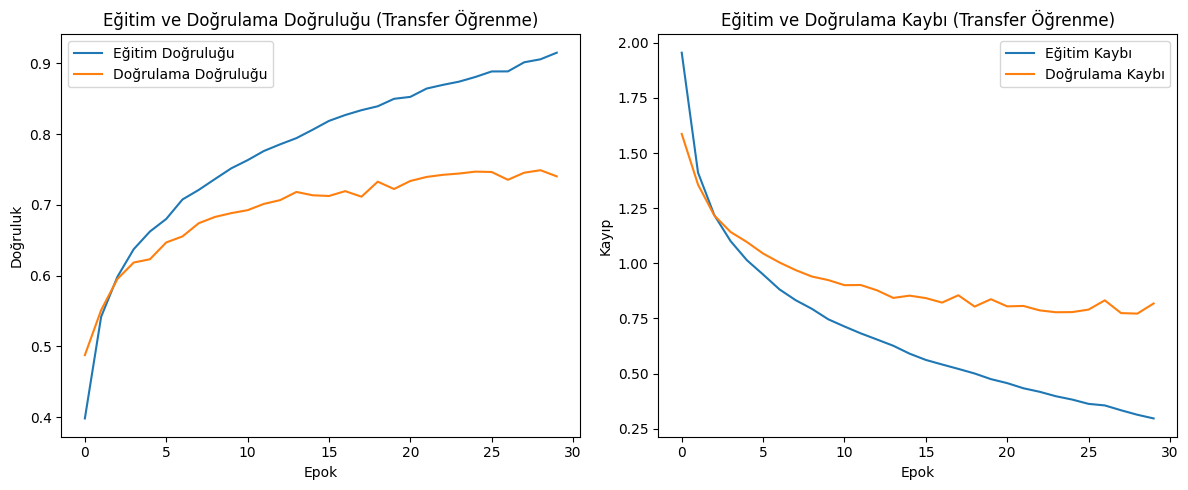

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_transfer.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history_transfer.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Eğitim ve Doğrulama Doğruluğu (Transfer Öğrenme)')
plt.xlabel('Epok')
plt.ylabel('Doğruluk')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['loss'], label='Eğitim Kaybı')
plt.plot(history_transfer.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Eğitim ve Doğrulama Kaybı (Transfer Öğrenme)')
plt.xlabel('Epok')
plt.ylabel('Kayıp')
plt.legend()

plt.tight_layout()
plt.show()

### Transfer Öğrenme Modelini Dengelenmiş ve Arttırılmış Veri Setiyle Eğitme

Şimdi daha önce tanımladığımız transfer öğrenme modelini, veri arttırma ve dengeleme uygulanmış `X_train_augmented_balanced_normalized` verisi üzerinde eğiteceğiz. Doğrulama için yine `X_test_split_normalized` ve `y_test_split` kullanılacak.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Re-initialize the VGG16 base model (to ensure fresh weights for the new training run)
base_model_reinitialized = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Freeze the base model layers
for layer in base_model_reinitialized.layers:
    layer.trainable = False

# Add custom classification layers on top of the re-initialized base model
x = base_model_reinitialized.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
predictions_reinitialized = Dense(num_classes, activation='softmax')(x) # num_classes is already defined

# Create the new transfer learning model
transfer_model_reinitialized = Model(inputs=base_model_reinitialized.input, outputs=predictions_reinitialized)

# Compile the re-initialized model
transfer_model_reinitialized.compile(optimizer=Adam(learning_rate=0.001),
                                     loss='sparse_categorical_crossentropy',
                                     metrics=['accuracy'])

print("Transfer learning model re-initialized and compiled for augmented data training.")

Transfer learning model re-initialized and compiled for augmented data training.


### Transfer Öğrenme Modelini Dengelenmiş ve Arttırılmış Veri Setiyle Eğitme (Yeniden Başlatıldı)

Yeniden başlattığımız transfer öğrenme modelini, veri arttırma ve dengeleme uygulanmış `X_train_augmented_balanced_normalized` verisi üzerinde eğiteceğiz. Doğrulama için yine `X_test_split_normalized` ve `y_test_split` kullanılacak.

In [ ]:
# Modeli dengelenmiş ve arttırılmış eğitim veri setiyle eğitme, orijinal test setini doğrulama için kullanma
history_transfer_augmented_reinitialized = transfer_model_reinitialized.fit(train_datagen.flow(X_train_augmented_balanced_normalized, y_train_augmented_balanced, batch_size=64),
                                                                           epochs=30,
                                                                           validation_data=(X_test_split_normalized, y_test_split),
                                                                           verbose=1)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 115ms/step - accuracy: 0.3943 - loss: 1.9773 - val_accuracy: 0.4949 - val_loss: 1.5333
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.5237 - loss: 1.4756 - val_accuracy: 0.5454 - val_loss: 1.3400
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.5600 - loss: 1.3323 - val_accuracy: 0.5656 - val_loss: 1.2701
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.5857 - loss: 1.2378 - val_accuracy: 0.5992 - val_loss: 1.1865
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 108ms/step - accuracy: 0.6151 - loss: 1.1538 - val_accuracy: 0.6169 - val_loss: 1.1214
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 104ms/step - accuracy: 0.6277 - loss: 1.1139 - val_accuracy: 0.6197 - val_loss: 1.0931
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.6358 - loss: 1.0671 - val_accuracy: 0.6366 - val_loss: 1.0524
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.6487 - loss: 1

### Transfer Öğrenme Modelinin Değerlendirmesi (Dengelenmiş ve Arttırılmış Veri Seti ile, Yeniden Başlatıldı)

Yeniden başlatılan transfer öğrenme modelinin, dengelenmiş ve arttırılmış eğitim verisiyle eğitildikten sonraki test seti üzerindeki performansını değerlendirelim.

In [ ]:
loss_transfer_augmented_reinitialized, accuracy_transfer_augmented_reinitialized = transfer_model_reinitialized.evaluate(X_test_split_normalized, y_test_split, verbose=0)
print(f"Test Seti Doğruluğu (Dengelenmiş ve Arttırılmış Veri ile Transfer Öğrenme, Yeniden Başlatıldı): {accuracy_transfer_augmented_reinitialized:.4f}")
print(f"Test Seti Kaybı (Dengelenmiş ve Arttırılmış Veri ile Transfer Öğrenme, Yeniden Başlatıldı): {loss_transfer_augmented_reinitialized:.4f}")

Test Seti Doğruluğu (Dengelenmiş ve Arttırılmış Veri ile Transfer Öğrenme, Yeniden Başlatıldı): 0.7277
Test Seti Kaybı (Dengelenmiş ve Arttırılmış Veri ile Transfer Öğrenme, Yeniden Başlatıldı): 0.7957


### Eğitim ve Doğrulama Grafikleri (Dengelenmiş ve Arttırılmış Veri ile Transfer Öğrenme, Yeniden Başlatıldı)

Yeniden başlatılan transfer öğrenme modelinin, dengelenmiş ve arttırılmış veri ile eğitimdeki performansını (doğruluk ve kayıp metrikleri) görselleştirelim.

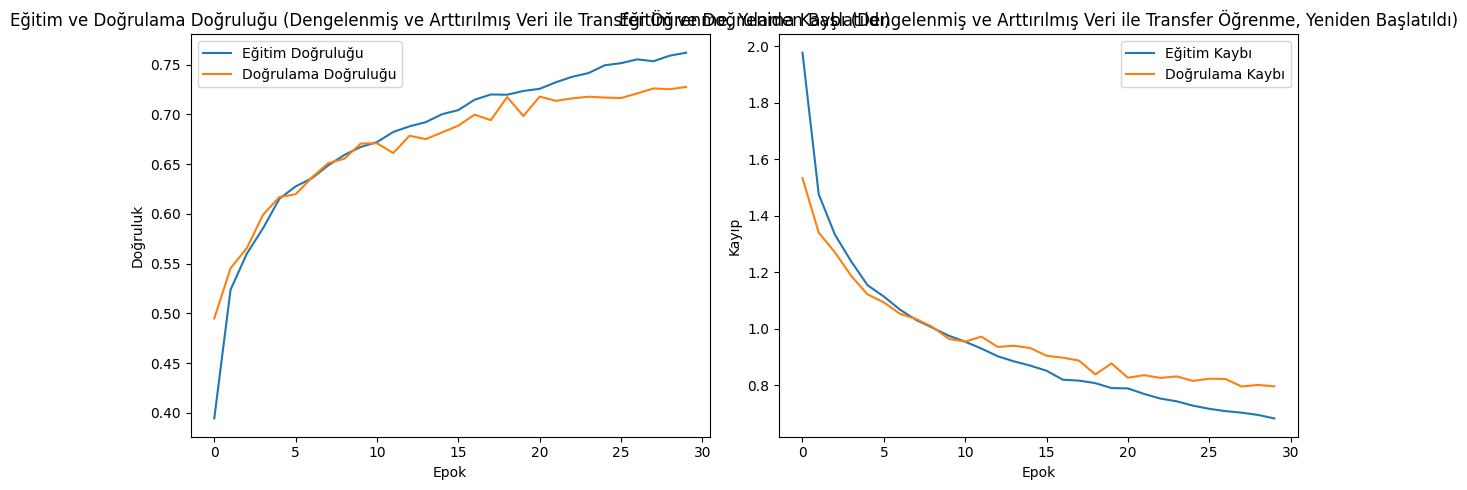

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_transfer_augmented_reinitialized.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history_transfer_augmented_reinitialized.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Eğitim ve Doğrulama Doğruluğu (Dengelenmiş ve Arttırılmış Veri ile Transfer Öğrenme, Yeniden Başlatıldı)')
plt.xlabel('Epok')
plt.ylabel('Doğruluk')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_transfer_augmented_reinitialized.history['loss'], label='Eğitim Kaybı')
plt.plot(history_transfer_augmented_reinitialized.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Eğitim ve Doğrulama Kaybı (Dengelenmiş ve Arttırılmış Veri ile Transfer Öğrenme, Yeniden Başlatıldı)')
plt.xlabel('Epok')
plt.ylabel('Kayıp')
plt.legend()

plt.tight_layout()
plt.show()